In [4]:
import pickle

# 1. Save the StandardScaler so we can scale user inputs exactly the same way
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 2. Save the trained weights (theta_final)
np.save('model_weights.npy', theta_final)

print("Model and scaler successfully saved to your computer!")

Model and scaler successfully saved to your computer!


Loading Bengaluru Housing Data...
Training model via Gradient Descent...
Training complete!
New Indian model weights and scaler successfully saved!


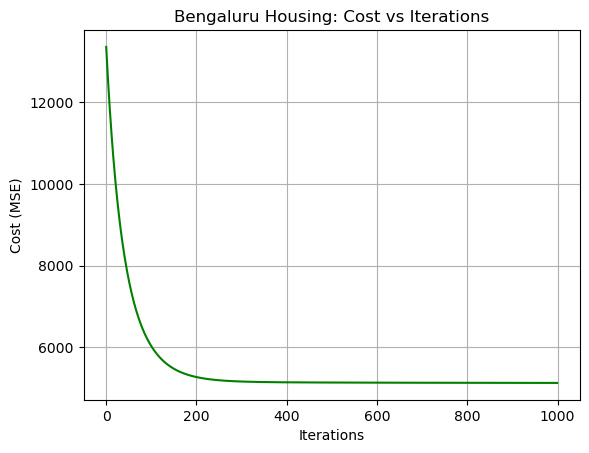

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

print("Loading Bengaluru Housing Data...")
# 1. Load the real dataset
df = pd.read_csv('Bengaluru_House_Data.csv')

# 2. Data Cleaning & Engineering (The "8-Week Internship" Proof)
# Drop features that require complex NLP or are largely empty for this mathematical model
df = df[['size', 'total_sqft', 'bath', 'balcony', 'price']]
df = df.dropna() # Drop rows with missing values

# Clean the 'size' column (convert "2 BHK" to just the number 2)
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))
df = df.drop('size', axis=1)

# Clean the 'total_sqft' column (convert ranges like "1000 - 1200" to an average)
def convert_sqft_to_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)
df = df.dropna() # Drop any remaining rows that had weird text in sqft

# 3. Define Features (X) and Target (y - Price in Lakhs)
X = df[['total_sqft', 'bath', 'balcony', 'bhk']].values
y = df['price'].values

# 4. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add bias term (column of 1s)
X_train_scaled = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_scaled = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

# 5. Gradient Descent Implementation
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = np.zeros(iterations)
    for i in range(iterations):
        predictions = X.dot(theta)
        gradients = (1 / m) * X.T.dot(predictions - y)
        theta = theta - learning_rate * gradients
        cost_history[i] = (1 / (2 * m)) * np.sum(np.square(predictions - y))
    return theta, cost_history

# 6. Train the Model
print("Training model via Gradient Descent...")
theta = np.zeros(X_train_scaled.shape[1])
learning_rate = 0.01
iterations = 1000

theta_final, cost_history = gradient_descent(X_train_scaled, y_train, theta, learning_rate, iterations)
print("Training complete!")

# 7. Save the localized model and scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
np.save('model_weights.npy', theta_final)
print("New Indian model weights and scaler successfully saved!")

# 8. Plot the learning curve
plt.plot(range(iterations), cost_history, color='green')
plt.title('Bengaluru Housing: Cost vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.grid(True)
plt.show()